# 3단계: 시/도별 개선율 및 SAW 결과 시각화

이 노트북은 `step2_sido_improvement_saw.ipynb`에서 생성한 CSV 파일을 읽어 시각화한다.

**확인할 그래프**
1. PM2.5 개선율 막대그래프
2. PM10 개선율 막대그래프
3. 편향 점검 그래프
   - 시/도별 PM2.5 결측률: 시행 전 vs 시행 후
   - 시/도별 PM10 결측률: 시행 전 vs 시행 후
   - 시/도별 측정소 수: 시행 전 vs 시행 후
4. PM2.5 개선율 vs 시행 후 PM2.5 절대농도 산점도
5. SAW 점수 막대그래프

그래프 해석의 핵심은 **개선율이 낮고, 시행 후 PM2.5 절대농도가 높은 지역**을 찾는 것이다.

## 0. 라이브러리 및 경로 설정

실행 위치가 프로젝트 루트일 수도 있고 `src` 폴더일 수도 있으므로, 두 경로를 모두 후보로 둔다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# 한글 그래프 깨짐 방지. Windows 환경에서는 Malgun Gothic이 보통 사용 가능하다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프 기본 스타일. 너무 화려하지 않게 보고서용으로 설정한다.
sns.set_theme(style="whitegrid", font="Malgun Gothic")


DATA_DIR_CANDIDATES = [
    Path("data/processed"),
    Path("../data/processed"),
]


def resolve_existing_dir(candidates: list[Path]) -> Path:
    """후보 폴더 중 실제 존재하는 첫 번째 경로를 반환한다."""
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"폴더를 찾을 수 없습니다: {candidates}")


DATA_DIR = resolve_existing_dir(DATA_DIR_CANDIDATES)

IMPROVEMENT_PATH = DATA_DIR / "sido_winter_improvement.csv"
BIAS_PATH = DATA_DIR / "sido_winter_bias_check.csv"
SAW_PATH = DATA_DIR / "sido_saw_input_equal_weight.csv"

print("데이터 폴더:", DATA_DIR)
print("개선율 파일:", IMPROVEMENT_PATH)
print("편향 점검 파일:", BIAS_PATH)
print("SAW 파일:", SAW_PATH)

데이터 폴더: ..\data\processed
개선율 파일: ..\data\processed\sido_winter_improvement.csv
편향 점검 파일: ..\data\processed\sido_winter_bias_check.csv
SAW 파일: ..\data\processed\sido_saw_input_equal_weight.csv


## 1. Step2 결과 CSV 읽기

세 파일을 읽는다.

- `sido_winter_improvement.csv`: 시행 전후 평균 및 개선율
- `sido_winter_bias_check.csv`: 측정소 수, 행 수, 결측률
- `sido_saw_input_equal_weight.csv`: SAW 기준값, 정규화 점수, 동일가중 순위

In [2]:
improvement = pd.read_csv(IMPROVEMENT_PATH)
bias = pd.read_csv(BIAS_PATH)
saw = pd.read_csv(SAW_PATH)

print("개선율:", improvement.shape)
print("편향 점검:", bias.shape)
print("SAW:", saw.shape)

improvement.head()

개선율: (17, 7)
편향 점검: (34, 6)
SAW: (17, 9)


,sido,pm25_before,pm25_after,pm10_before,pm10_after,pm25_improvement_rate,pm10_improvement_rate
0,충남,30.435122,27.619992,51.508348,47.354286,9.249608,8.064832
1,세종,29.815828,26.073310,52.310728,46.276427,12.552117,11.535496
2,인천,30.947629,25.187223,52.565747,44.061764,18.613400,16.177803
3,서울,31.948771,25.613491,53.532668,44.028373,19.829495,17.754197
4,대구,29.293195,22.929954,48.707147,40.175097,21.722591,17.517039


## 2. PM2.5 개선율 막대그래프

PM2.5 개선율이 낮은 지역일수록 개선이 미흡한 지역이다. 따라서 낮은 순서로 정렬해 확인한다.

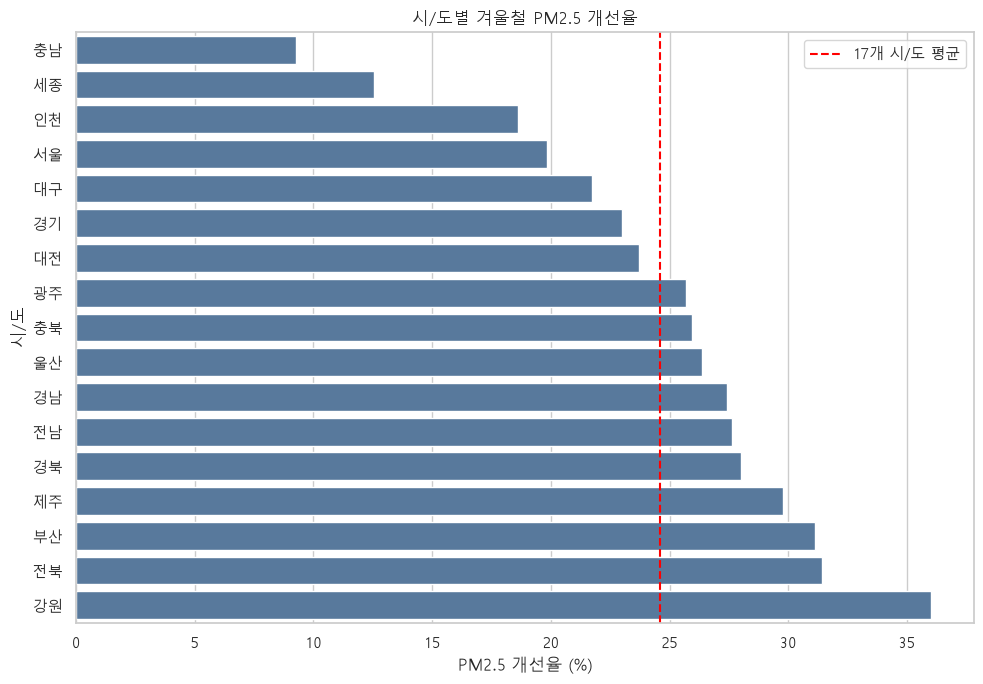

In [3]:
plot_df = improvement.sort_values("pm25_improvement_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="pm25_improvement_rate",
    y="sido",
    ax=ax,
    color="#4C78A8",
)
ax.axvline(plot_df["pm25_improvement_rate"].mean(), color="red", linestyle="--", label="17개 시/도 평균")
ax.set_title("시/도별 겨울철 PM2.5 개선율")
ax.set_xlabel("PM2.5 개선율 (%)")
ax.set_ylabel("시/도")
ax.legend()
plt.tight_layout()
plt.show()

## 3. PM10 개선율 막대그래프

PM10 개선율도 같은 방식으로 확인한다. PM2.5와 PM10의 개선 양상이 같은지 비교하는 데 쓴다.

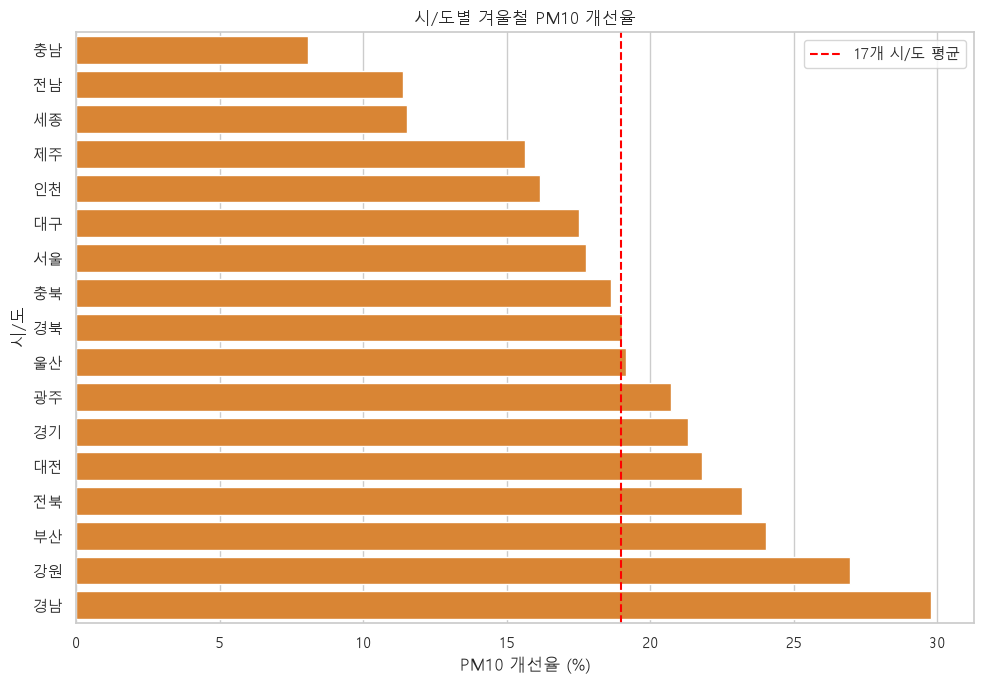

In [4]:
plot_df = improvement.sort_values("pm10_improvement_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="pm10_improvement_rate",
    y="sido",
    ax=ax,
    color="#F58518",
)
ax.axvline(plot_df["pm10_improvement_rate"].mean(), color="red", linestyle="--", label="17개 시/도 평균")
ax.set_title("시/도별 겨울철 PM10 개선율")
ax.set_xlabel("PM10 개선율 (%)")
ax.set_ylabel("시/도")
ax.legend()
plt.tight_layout()
plt.show()

## 4. 편향 점검 1: PM2.5 결측률

PM2.5는 과거 기간에 결측이 많을 수 있다. 시행 전/후 결측률 차이가 큰 지역은 개선율 해석에 주의해야 한다.

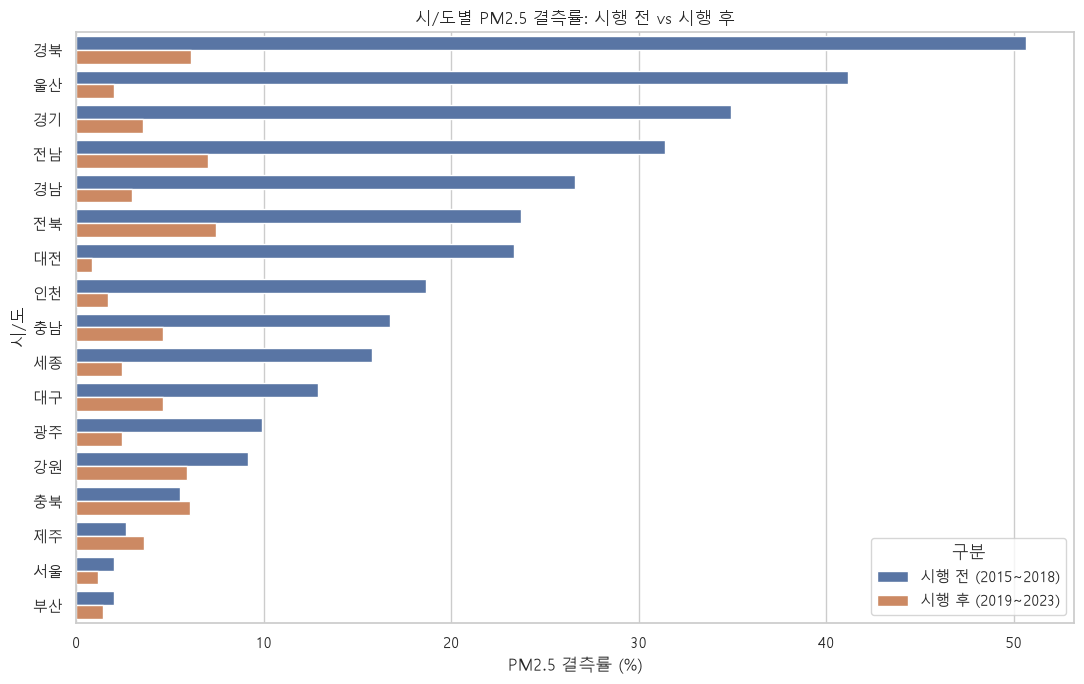

In [5]:
# 시행 전 PM2.5 결측률이 높은 순서로 시/도 순서를 정한다.
before_missing_order = (
    bias[bias["period"].str.startswith("시행 전")]
    .sort_values("pm25_missing_rate", ascending=False)["sido"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=bias,
    x="pm25_missing_rate",
    y="sido",
    hue="period",
    order=before_missing_order,
    ax=ax,
)
ax.set_title("시/도별 PM2.5 결측률: 시행 전 vs 시행 후")
ax.set_xlabel("PM2.5 결측률 (%)")
ax.set_ylabel("시/도")
ax.legend(title="구분")
plt.tight_layout()
plt.show()

## 5. 편향 점검 2: PM10 결측률

PM10 결측률도 함께 확인한다. PM2.5보다 결측률이 낮은 편인지, 특정 시/도에서 시행 전후 차이가 큰지 비교한다.

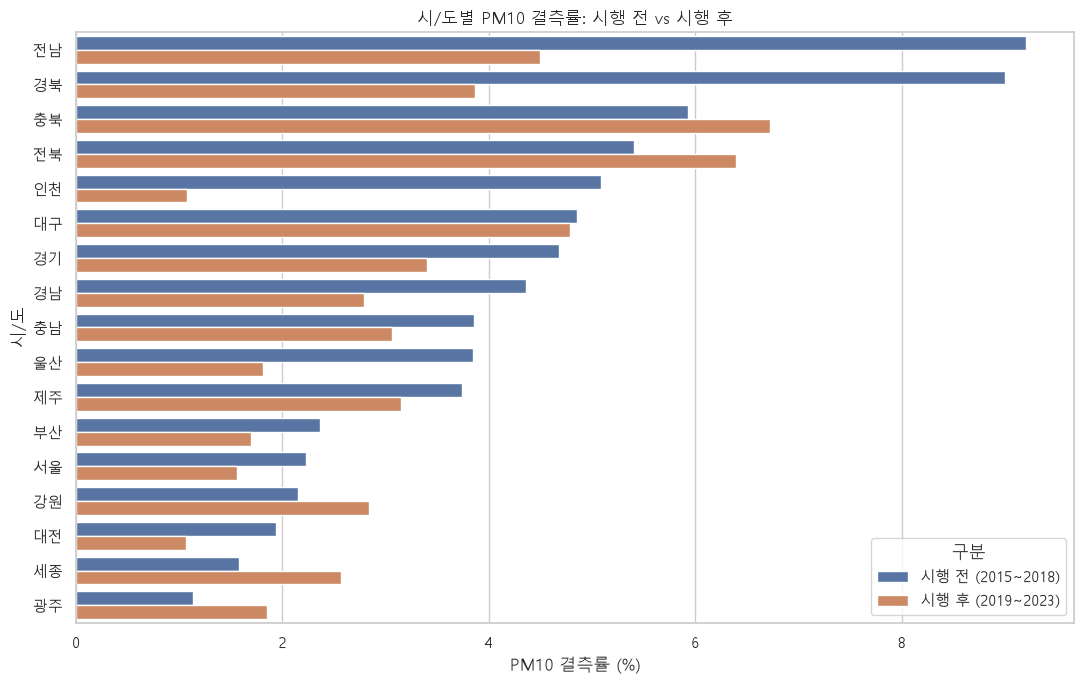

In [11]:
# 시행 전 PM10 결측률이 높은 순서로 시/도 순서를 정한다.
before_pm10_missing_order = (
    bias[bias["period"].str.startswith("시행 전")]
    .sort_values("pm10_missing_rate", ascending=False)["sido"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=bias,
    x="pm10_missing_rate",
    y="sido",
    hue="period",
    order=before_pm10_missing_order,
    ax=ax,
)
ax.set_title("시/도별 PM10 결측률: 시행 전 vs 시행 후")
ax.set_xlabel("PM10 결측률 (%)")
ax.set_ylabel("시/도")
ax.legend(title="구분")
plt.tight_layout()
plt.show()

## 6. 편향 점검 3: 측정소 수

시행 전/후 측정소 수가 많이 달라진 지역은 관측망 확충 또는 변경의 영향을 받을 수 있다.

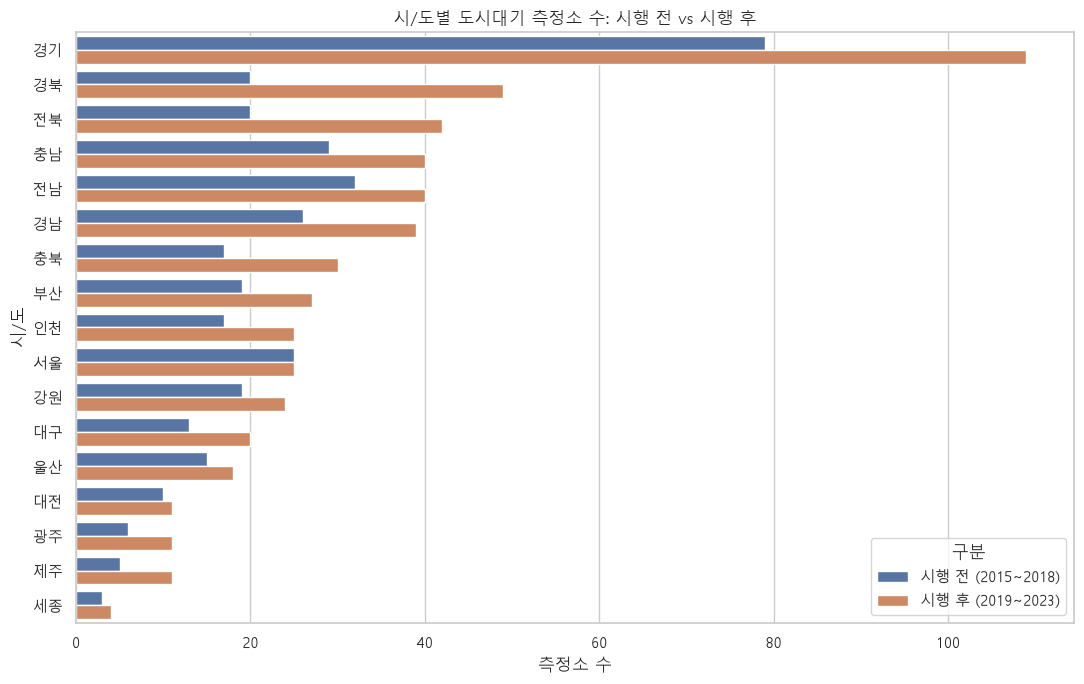

In [7]:
# 시행 후 측정소 수가 많은 순서로 시/도 순서를 정한다.
after_station_order = (
    bias[bias["period"].str.startswith("시행 후")]
    .sort_values("station_count", ascending=False)["sido"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=bias,
    x="station_count",
    y="sido",
    hue="period",
    order=after_station_order,
    ax=ax,
)
ax.set_title("시/도별 도시대기 측정소 수: 시행 전 vs 시행 후")
ax.set_xlabel("측정소 수")
ax.set_ylabel("시/도")
ax.legend(title="구분")
plt.tight_layout()
plt.show()

## 7. PM2.5 개선율 vs 시행 후 PM2.5 절대농도 산점도

의사결정 관점에서 가장 중요한 그래프다.

- 왼쪽: 개선율이 낮음
- 위쪽: 시행 후 PM2.5 절대농도가 높음

따라서 **왼쪽 위**에 있는 지역은 개선이 미흡하면서 현재 오염 부담도 큰 우선관리 후보로 볼 수 있다.

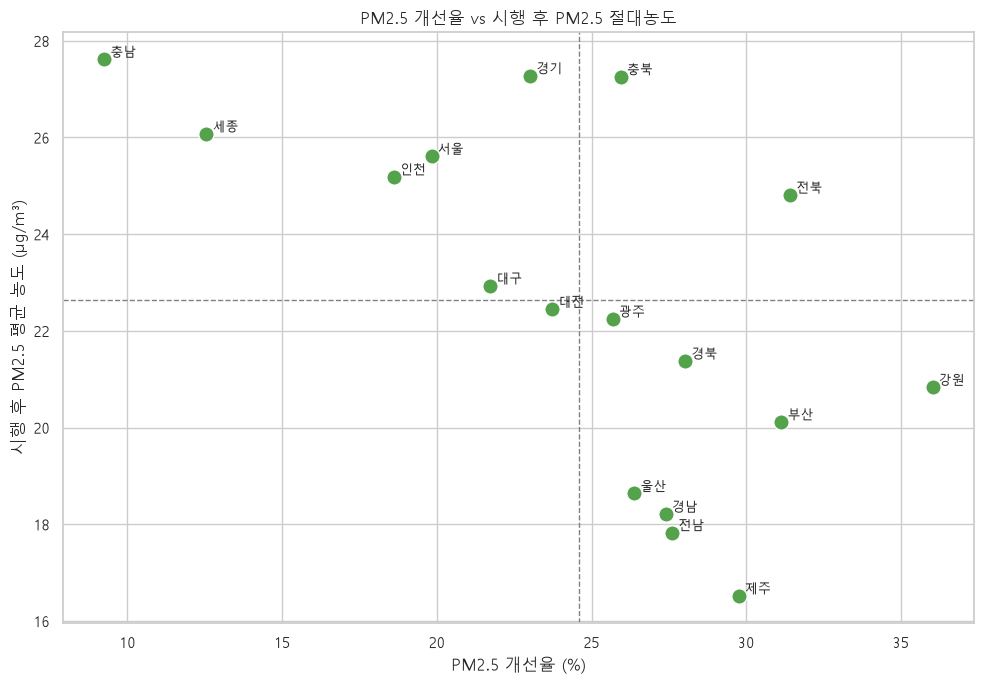

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=improvement,
    x="pm25_improvement_rate",
    y="pm25_after",
    s=120,
    color="#54A24B",
    ax=ax,
)

# 평균선을 그어 사분면 해석을 쉽게 만든다.
x_mean = improvement["pm25_improvement_rate"].mean()
y_mean = improvement["pm25_after"].mean()
ax.axvline(x_mean, color="gray", linestyle="--", linewidth=1)
ax.axhline(y_mean, color="gray", linestyle="--", linewidth=1)

# 각 점에 시/도명을 표시한다.
for _, row in improvement.iterrows():
    ax.text(
        row["pm25_improvement_rate"] + 0.2,
        row["pm25_after"] + 0.05,
        row["sido"],
        fontsize=9,
    )

ax.set_title("PM2.5 개선율 vs 시행 후 PM2.5 절대농도")
ax.set_xlabel("PM2.5 개선율 (%)")
ax.set_ylabel("시행 후 PM2.5 평균 농도 (µg/m³)")
plt.tight_layout()
plt.show()

## 8. SAW 점수 막대그래프

동일가중 SAW 기준 우선순위 결과를 점수 순으로 확인한다. 점수가 높을수록 관리 자원 우선 배분 후보에 가깝다.

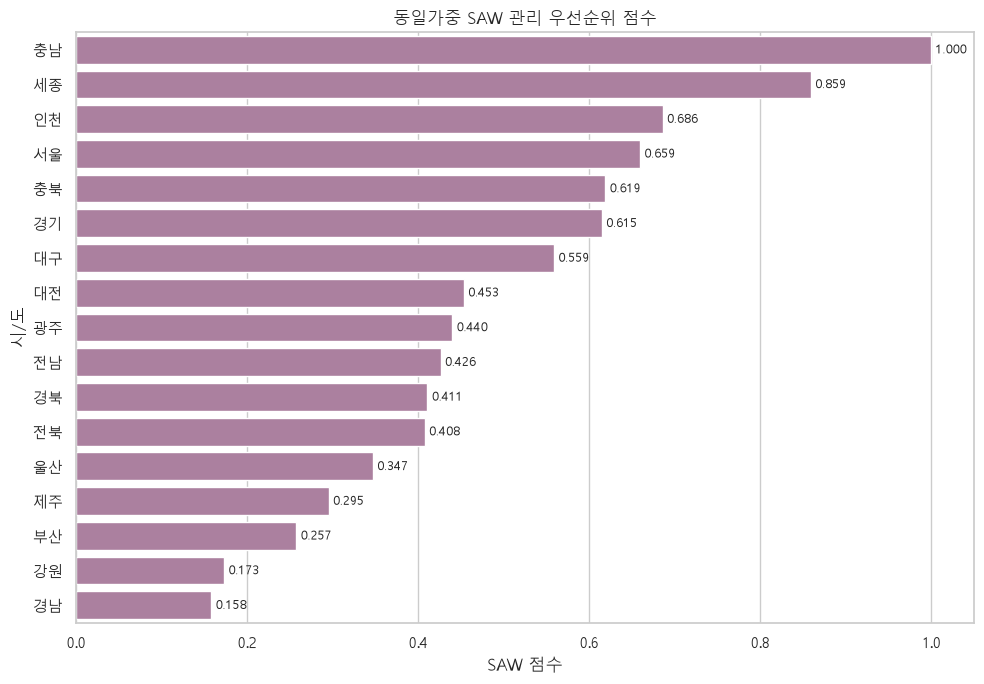

In [9]:
plot_df = saw.sort_values("saw_score_equal_weight", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_df,
    x="saw_score_equal_weight",
    y="sido",
    ax=ax,
    color="#B279A2",
)
ax.set_title("동일가중 SAW 관리 우선순위 점수")
ax.set_xlabel("SAW 점수")
ax.set_ylabel("시/도")

# 막대 오른쪽에 순위를 표시한다.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 9. 해석 메모

보고서에는 다음 흐름으로 해석하면 자연스럽다.

1. PM2.5/PM10 개선율 막대그래프로 시/도별 개선폭 차이를 확인한다.
2. 편향 점검 그래프로 PM2.5/PM10 결측률과 측정소 수 차이를 확인한다.
3. 산점도로 개선율이 낮고 시행 후 PM2.5 농도가 높은 지역을 찾는다.
4. SAW 점수 막대그래프로 최종 우선순위 후보를 제시한다.

주의할 점은 이 분석이 전후 비교 기반이라는 것이다. 코로나19, 중국발 오염 변화, 산업 구조 변화, 측정망 변화 같은 외부 요인을 완전히 분리한 인과효과 분석은 아니다.